# L3-C - Linear Quantization II: Per Channel Quantization

In this lesson, you will continue to learn about different granularities of performing linear quantization. You will cover `per channel` in this notebook.

In [1]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import torch


def quantization_error(tensor, dequantized_tensor):
    return (dequantized_tensor - tensor).abs().square().mean()


def linear_q_with_scale_and_zero_point(r_tensor, scale, zero_point, dtype=torch.int8):
    """
    Performs simple linear quantization given
    the scale and zero-point.
    """

    # scale tensor and add the zero point
    scaled_and_shifted_tensor = r_tensor / scale + zero_point

    # round the tensor
    rounded_tensor = torch.round(scaled_and_shifted_tensor)

    # we need to clamp to the min/max value of the specified dtype
    q_min, q_max = torch.iinfo(dtype).min, torch.iinfo(dtype).max
    q_tensor = rounded_tensor.clamp(q_min, q_max).to(dtype)
    return q_tensor


def linear_dequantization(quantized_tensor, scale, zero_point):
    """
    Linear de-quantization
    """
    dequantized_tensor = scale * (quantized_tensor.float() - zero_point)

    return dequantized_tensor


def plot_matrix(tensor, ax, title, vmin=0, vmax=1, cmap=None):
    """
    Plot a heatmap of tensors using seaborn
    """
    sns.heatmap(tensor.cpu().numpy(), ax=ax, vmin=vmin, vmax=vmax, cmap=cmap, annot=True, fmt=".2f", cbar=False)
    ax.set_title(title)
    ax.set_yticklabels([])
    ax.set_xticklabels([])


def plot_quantization_errors(original_tensor, quantized_tensor, dequantized_tensor, dtype=torch.int8, n_bits=8):
    """
    A method that plots 4 matrices, the original tensor, the quantized tensor
    the de-quantized tensor and the error tensor.
    """
    # Get a figure of 4 plots
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))

    # Plot the first matrix
    plot_matrix(original_tensor, axes[0], "Original Tensor", cmap=ListedColormap(["white"]))

    # Get the quantization range and plot the quantized tensor
    q_min, q_max = torch.iinfo(dtype).min, torch.iinfo(dtype).max
    plot_matrix(
        quantized_tensor, axes[1], f"{n_bits}-bit Linear Quantized Tensor", vmin=q_min, vmax=q_max, cmap="coolwarm"
    )

    # Plot the de-quantized tensors
    plot_matrix(dequantized_tensor, axes[2], "Dequantized Tensor", cmap="coolwarm")

    # Get the quantization errors
    q_error_tensor = abs(original_tensor - dequantized_tensor)
    plot_matrix(q_error_tensor, axes[3], "Quantization Error Tensor", cmap=ListedColormap(["white"]))

    fig.tight_layout()
    plt.show()


def get_q_scale_and_zero_point(r_tensor, dtype=torch.int8):
    """
    Get quantization parameters (scale, zero point)
    for a floating point tensor
    """
    q_min, q_max = torch.iinfo(dtype).min, torch.iinfo(dtype).max
    r_min, r_max = r_tensor.min().item(), r_tensor.max().item()

    scale = (r_max - r_min) / (q_max - q_min)

    zero_point = q_min - (r_min / scale)

    # clip the zero_point to fall in [quantized_min, quantized_max]
    if zero_point < q_min or zero_point > q_max:
        zero_point = q_min
    else:
        # round and cast to int
        zero_point = int(round(zero_point))
    return scale, zero_point


############# From the previous lesson(s) of "Linear Quantization II"
def get_q_scale_symmetric(tensor, dtype=torch.int8):
    r_max = tensor.abs().max().item()
    q_max = torch.iinfo(dtype).max

    # return the scale
    return r_max / q_max


###################################

In [2]:
import torch

## Different Granularities for Quantization
- For simplicity, you'll perform these using Symmetric mode.

### Per Channel
- Implement `Per Channel` Symmetric Quantization
- `dim` parameter decides if it needs to be along the rows or columns

In [3]:
def linear_q_symmetric_per_channel(tensor, dim, dtype=torch.int8):

    # 1 - dim means "the other dimension"
    rs_max = tensor.abs().max(dim=1 - dim, keepdim=True).values
    q_max = torch.iinfo(dtype).max

    # return the scale
    scales = rs_max / q_max

    quantized_tensor = linear_q_with_scale_and_zero_point(tensor, scale=scales, zero_point=0, dtype=dtype)

    return quantized_tensor, scales

In [4]:
test_tensor = torch.tensor([[191.6, -13.5, 728.6], [92.14, 295.5, -184], [0, 684.6, 245.5]])

- `dim = 0`, along the rows
- `dim = 1`, along the columns

In [5]:
dim = 0
output_dim = test_tensor.shape[dim]
output_dim

3

- Iterate through each row to calculate its `scale`.

In [6]:
scale = torch.zeros(output_dim)

for index in range(output_dim):
    sub_tensor = test_tensor.select(dim, index)
    # print(sub_tensor)
    scale[index] = get_q_scale_symmetric(sub_tensor)

scale = scale[:, None]

# copy to be used later
copy_scale = scale

scale

tensor([[5.7370],
        [2.3268],
        [5.3906]])

In [7]:
linear_q_symmetric_per_channel(test_tensor, dim=0, dtype=torch.int8)[1]

tensor([[5.7370],
        [2.3268],
        [5.3906]])

#### Understanding tensor by tensor division using `view` function

In [8]:
m = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
m

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [9]:
s = torch.tensor([1, 5, 10])
print(s)
print(s.shape)
print(s.view(1, 3).shape)

# alternate way
print(s.view(1, -1).shape)
print(s.view(-1, 1).shape)

tensor([ 1,  5, 10])
torch.Size([3])
torch.Size([1, 3])
torch.Size([1, 3])
torch.Size([3, 1])


##### Along the row division

In [10]:
scale = torch.tensor([[1], [5], [10]])
scale.shape

torch.Size([3, 1])

In [11]:
m / scale

tensor([[1.0000, 2.0000, 3.0000],
        [0.8000, 1.0000, 1.2000],
        [0.7000, 0.8000, 0.9000]])

##### Along the column division

In [12]:
scale = torch.tensor([[1, 5, 10]])
scale.shape

torch.Size([1, 3])

In [13]:
m / scale

tensor([[1.0000, 0.4000, 0.3000],
        [4.0000, 1.0000, 0.6000],
        [7.0000, 1.6000, 0.9000]])

#### Coming back to quantizing the tensor

In [14]:
# the scale you got earlier
scale = copy_scale

scale, scale.shape

(tensor([[5.7370],
         [2.3268],
         [5.3906]]),
 torch.Size([3, 1]))

In [15]:
quantized_tensor = linear_q_with_scale_and_zero_point(test_tensor, scale=scale, zero_point=0)
quantized_tensor

tensor([[ 33,  -2, 127],
        [ 40, 127, -79],
        [  0, 127,  46]], dtype=torch.int8)

- Now, put all this in `linear_q_symmetric_per_channel` function defined earlier.

In [16]:
def linear_q_symmetric_per_channel_2(r_tensor, dim, dtype=torch.int8):

    output_dim = r_tensor.shape[dim]
    # store the scales
    scale = torch.zeros(output_dim)

    for index in range(output_dim):
        sub_tensor = r_tensor.select(dim, index)
        scale[index] = get_q_scale_symmetric(sub_tensor, dtype=dtype)

    # reshape the scale
    scale_shape = [1] * r_tensor.dim()
    scale_shape[dim] = -1
    scale = scale.view(scale_shape)
    quantized_tensor = linear_q_with_scale_and_zero_point(r_tensor, scale=scale, zero_point=0, dtype=dtype)

    return quantized_tensor, scale

In [17]:
test_tensor = torch.tensor([[191.6, -13.5, 728.6], [92.14, 295.5, -184], [0, 684.6, 245.5]])

In [18]:
### along the rows (dim = 0)
quantized_tensor_0, scale_0 = linear_q_symmetric_per_channel_2(test_tensor, dim=0)
quantized_tensor_0_2, scale_0_2 = linear_q_symmetric_per_channel(test_tensor, dim=0)
assert torch.allclose(quantized_tensor_0, quantized_tensor_0_2)
assert torch.allclose(scale_0, scale_0_2)

### along the columns (dim = 1)
quantized_tensor_1, scale_1 = linear_q_symmetric_per_channel_2(test_tensor, dim=1)
quantized_tensor_1_2, scale_1_2 = linear_q_symmetric_per_channel(test_tensor, dim=1)
assert torch.allclose(quantized_tensor_1, quantized_tensor_1_2)
assert torch.allclose(scale_1, scale_1_2)

In [23]:
test_tensor_large = torch.randn(1000, 1000)

### along the rows (dim = 0)
%timeit linear_q_symmetric_per_channel_2(test_tensor_large, dim=0)
%timeit linear_q_symmetric_per_channel(test_tensor_large, dim=0)

### along the columns (dim = 1)
%timeit linear_q_symmetric_per_channel_2(test_tensor_large, dim=1)
%timeit linear_q_symmetric_per_channel(test_tensor_large, dim=1)

5.96 ms ± 101 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.32 ms ± 58.6 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
6.29 ms ± 19.8 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.4 ms ± 74.7 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


- Plot the quantization error for along the rows.

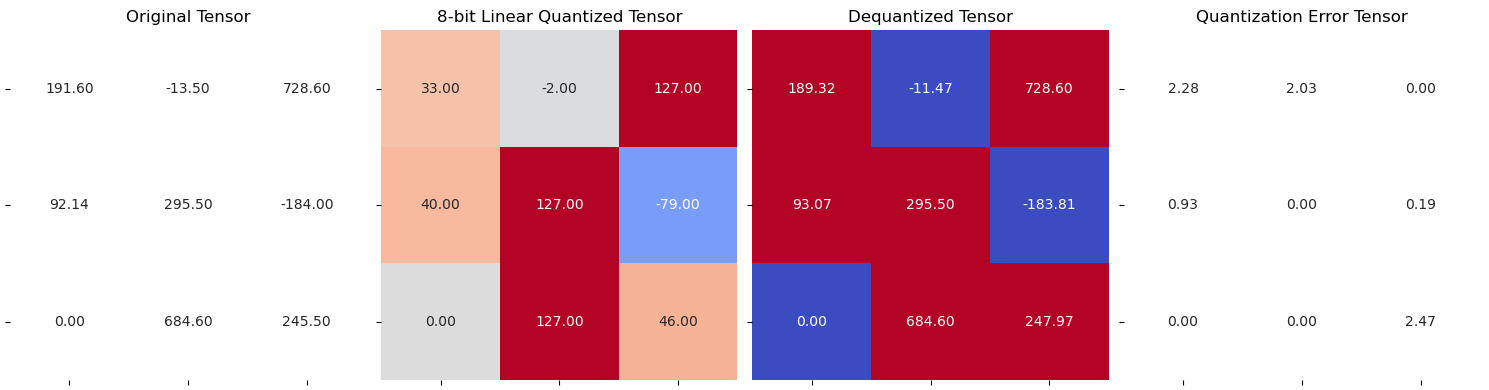

In [24]:
dequantized_tensor_0 = linear_dequantization(quantized_tensor_0, scale_0, 0)

plot_quantization_errors(test_tensor, quantized_tensor_0, dequantized_tensor_0)

In [25]:
print(f"Quantization Error: {quantization_error(test_tensor, dequantized_tensor_0)}")

Quantization Error: 1.8084441423416138


- Plot the quantization error for along the columns.

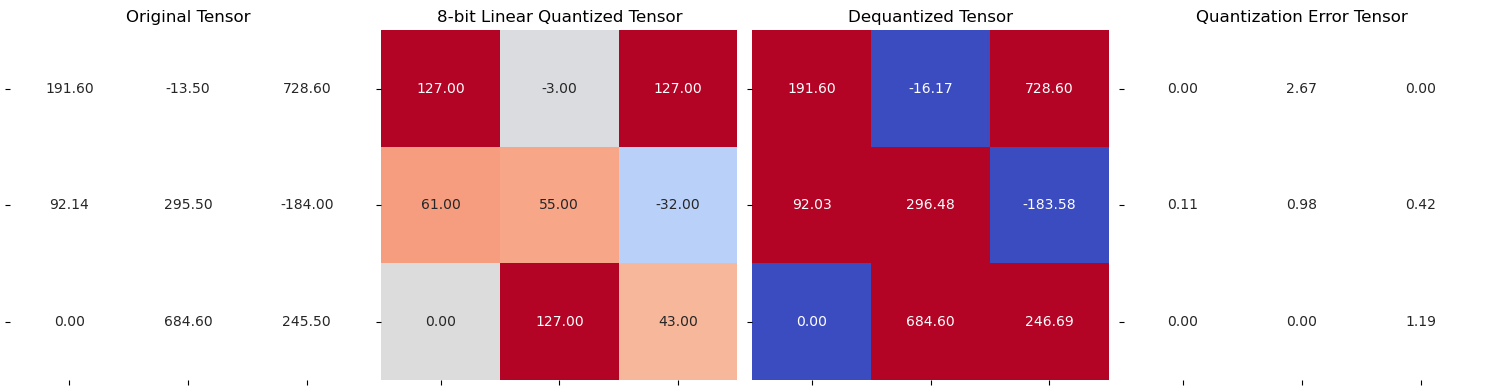

Quantization Error: 1.0781488418579102


In [26]:
dequantized_tensor_1 = linear_dequantization(quantized_tensor_1, scale_1, 0)

plot_quantization_errors(test_tensor, quantized_tensor_1, dequantized_tensor_1, n_bits=8)

print(f"Quantization Error: {quantization_error(test_tensor, dequantized_tensor_1)}")